In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

# Set random seed for consistency
np.random.seed(42)
n_samples = 150

# Generate realistic feature ranges
study_hours = np.random.uniform(1.0, 9.5, n_samples).round(1)
prev_scores = np.random.uniform(40.0, 98.0, n_samples).round(1)
sleep_hours = np.random.uniform(4.5, 9.0, n_samples).round(1)

# Linear combination with slight variance
performance = (2.8 * study_hours + 0.65 * prev_scores + 1.2 * sleep_hours + np.random.normal(0, 2.5, n_samples)).round(1)
performance = np.clip(performance, 30.0, 100.0)

# Build and export DataFrame
df_student = pd.DataFrame({
    'Study_Hours': study_hours,
    'Previous_Scores': prev_scores,
    'Sleep_Hours': sleep_hours,
    'Performance_Index': performance
})

df_student.to_csv('student_performance.csv', index=False)
print("student_performance.csv successfully generated!")

student_performance.csv successfully generated!


In [3]:
df = pd.read_csv("student_performance.csv")

print("Shape:", df.shape)
print("\nMissing values check:\n", df.isnull().sum())
print("\nDescriptive statistics:")
display(df.describe())
df.head()

Shape: (150, 4)

Missing values check:
 Study_Hours          0
Previous_Scores      0
Sleep_Hours          0
Performance_Index    0
dtype: int64

Descriptive statistics:


,Study_Hours,Previous_Scores,Sleep_Hours,Performance_Index
count,150.000000,150.000000,150.00000,150.000000
mean,5.018000,70.018667,6.73600,67.702000
std,2.521799,16.898542,1.35826,13.292656
min,1.000000,40.300000,4.50000,37.300000
25%,2.825000,54.400000,5.60000,58.825000
50%,4.800000,72.250000,6.80000,67.050000
75%,7.350000,83.975000,7.90000,78.700000
max,9.400000,97.400000,9.00000,91.500000


,Study_Hours,Previous_Scores,Sleep_Hours,Performance_Index
0,4.2,92.7,4.7,78.4
1,9.1,53.9,6.9,72.5
2,7.2,48.4,6.9,62.0
3,6.1,68.4,7.4,70.0
4,2.3,97.2,7.8,78.9


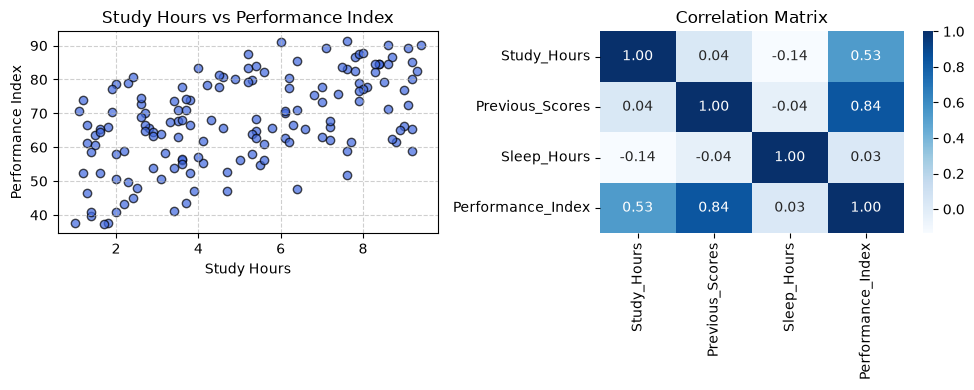

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 4))

# Plot 1: Study Hours vs Score
plt.subplot(1, 2, 1)
plt.scatter(df['Study_Hours'], df['Performance_Index'], color='royalblue', edgecolors='k', alpha=0.7)
plt.title("Study Hours vs Performance Index")
plt.xlabel("Study Hours")
plt.ylabel("Performance Index")
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Correlation Heatmap
plt.subplot(1, 2, 2)
sns.heatmap(df.corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Split features and target
X = df[['Study_Hours', 'Previous_Scores', 'Sleep_Hours']]
y = df['Performance_Index']

# 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Output coefficients
print("Intercept:", model.intercept_)
for col, coef in zip(X.columns, model.coef_):
    print(f"Coefficient ({col}): {coef:.4f}")

Intercept: 1.0076852993756802
Coefficient (Study_Hours): 2.7350
Coefficient (Previous_Scores): 0.6376
Coefficient (Sleep_Hours): 1.2365


R-squared Score: 96.46%
Root Mean Squared Error (RMSE): 2.57


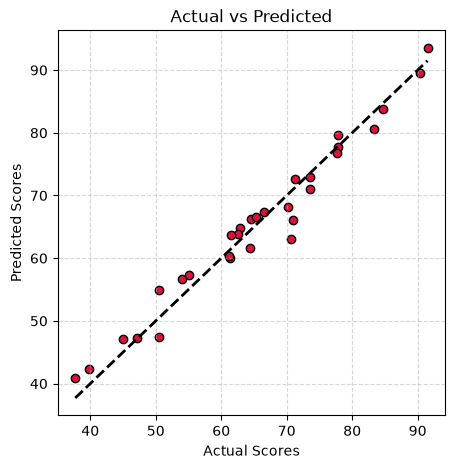

In [6]:
from sklearn.metrics import r2_score, mean_squared_error

# Predict on test set
y_pred = model.predict(X_test)

# Metrics
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R-squared Score: {r2 * 100:.2f}%")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

# Actual vs. Predicted comparison plot
plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_pred, color='crimson', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")
plt.title("Actual vs Predicted")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [7]:
study = float(input("Enter study hours (e.g. 6): "))
prev = float(input("Enter previous exam score (e.g. 80): "))
sleep = float(input("Enter sleep hours (e.g. 7): "))

custom_pred = model.predict([[study, prev, sleep]])[0]
print(f"\n---> Predicted Performance Index: {min(100.0, round(custom_pred, 2))}%")

Enter study hours (e.g. 6):  5
Enter previous exam score (e.g. 80):  82
Enter sleep hours (e.g. 7):  6



---> Predicted Performance Index: 74.39%


C:\Users\PIYUSH\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [10]:
import pandas as pd

study = float(input("Enter study hours (e.g. 6): "))
prev = float(input("Enter previous exam score (e.g. 80): "))
sleep = float(input("Enter sleep hours (e.g. 7): "))

# Wrap input in a DataFrame with matching column names
input_data = pd.DataFrame([[study, prev, sleep]], columns=['Study_Hours', 'Previous_Scores', 'Sleep_Hours'])

custom_pred = model.predict(input_data)[0]
final_score = max(0.0, min(100.0, round(custom_pred, 2)))

print(f"\n---> Predicted Performance Index: {final_score}%")

Enter study hours (e.g. 6):  9
Enter previous exam score (e.g. 80):  95
Enter sleep hours (e.g. 7):  8



---> Predicted Performance Index: 96.09%
